# HR Employee Retention — Business Analytics Deep Dive

## 0. data loading

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

df = pd.read_csv('HR_Dataset.csv')
df.columns = df.columns.str.lower()
df.shape

(14999, 10)

In [14]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.380,0.530,2,157,3,0,1,0,sales,low
1,0.800,0.860,5,262,6,0,1,0,sales,medium
2,0.110,0.880,7,272,4,0,1,0,sales,medium
3,0.720,0.870,5,223,5,0,1,0,sales,low
4,0.370,0.520,2,159,3,0,1,0,sales,low


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


**What we have:** 14,999 employees, 10 columns.

**Variables at a glance**

| Column | Type | What it means |
|---|---|---|
| `satisfaction_level` | numeric 0–1 | Self-reported job satisfaction |
| `last_evaluation` | numeric 0–1 | Most recent performance score |
| `number_project` | integer 2–7 | Projects handled |
| `average_montly_hours` | integer | Avg hours worked per month |
| `time_spend_company` | integer 2–10 | Years at the company |
| `work_accident` | 0/1 | Had a workplace accident |
| `left` | 0/1 | **Target** — whether the employee left |
| `promotion_last_5years` | 0/1 | Promoted in last 5 years |
| `department` | categorical (10) | Sales, IT, HR, etc. |
| `salary` | categorical (low/medium/high) | Self-explanatory |

## 1. Data quality check

In [16]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

Duplicate rows: 3008


In [17]:
# Note: 'salary' is ordered (low < medium < high). We should store it as an ordered category, not just text.
salary_order = pd.CategoricalDtype(categories=['low', 'medium', 'high'], ordered=True)
df['salary'] = df['salary'].astype(salary_order)

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
satisfaction_level,"14,999.000",NaN,NaN,NaN,0.613,0.249,0.090,0.440,0.640,0.820,1.000
last_evaluation,"14,999.000",NaN,NaN,NaN,0.716,0.171,0.360,0.560,0.720,0.870,1.000
number_project,"14,999.000",NaN,NaN,NaN,3.803,1.233,2.000,3.000,4.000,5.000,7.000
average_montly_hours,"14,999.000",NaN,NaN,NaN,201.050,49.943,96.000,156.000,200.000,245.000,310.000
time_spend_company,"14,999.000",NaN,NaN,NaN,3.498,1.460,2.000,3.000,3.000,4.000,10.000
work_accident,"14,999.000",NaN,NaN,NaN,0.145,0.352,0.000,0.000,0.000,0.000,1.000
left,"14,999.000",NaN,NaN,NaN,0.238,0.426,0.000,0.000,0.000,0.000,1.000
promotion_last_5years,"14,999.000",NaN,NaN,NaN,0.021,0.144,0.000,0.000,0.000,0.000,1.000
department,14999,10,sales,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,14999,3,low,7316,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Quality notes**

- No missing values.
- 3,008 **exact duplicate rows**.
- `salary` is now an ordered category — useful for plots and modeling.

## 2. how many are leaving?

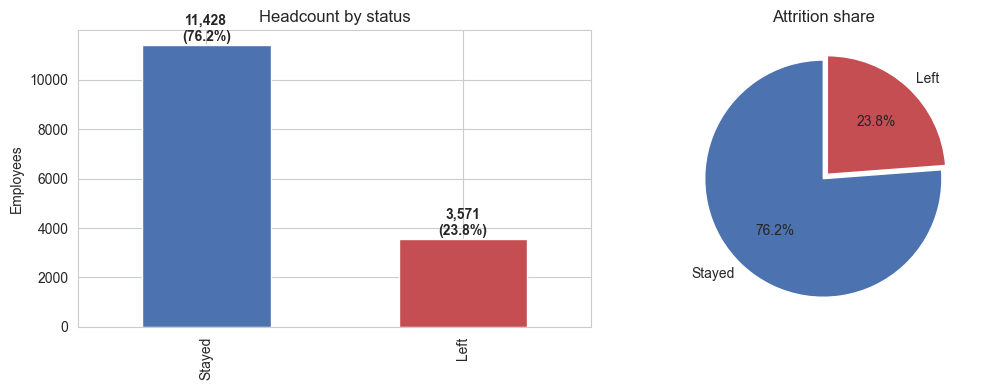

In [19]:
turnover = df['left'].value_counts().rename({0:'Stayed', 1:'Left'})
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
turnover.plot(kind='bar', ax=ax[0], color=['#4C72B0', '#C44E52'])
ax[0].set_title('Headcount by status'); ax[0].set_ylabel('Employees'); ax[0].set_xlabel('')
for i, v in enumerate(turnover.values):
    ax[0].text(i, v + 150, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

df['left'].value_counts(normalize=True).rename({0:'Stayed', 1:'Left'}).plot(
    kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=90,
    colors=['#4C72B0', '#C44E52'], explode=(0, 0.05)
)
ax[1].set_title('Attrition share'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

> **Insight:** Roughly **1 in 4** employees leaves the company, that is high for a typical white-collar firm an annual attrition rate of 10–15% is considered unhealthy. The replacement cost is usually 50–200% of annual salary depending on seniority, so even a 1-point reduction in attrition saves real money.

## 3. Univariate EDA — what does each variable look like?

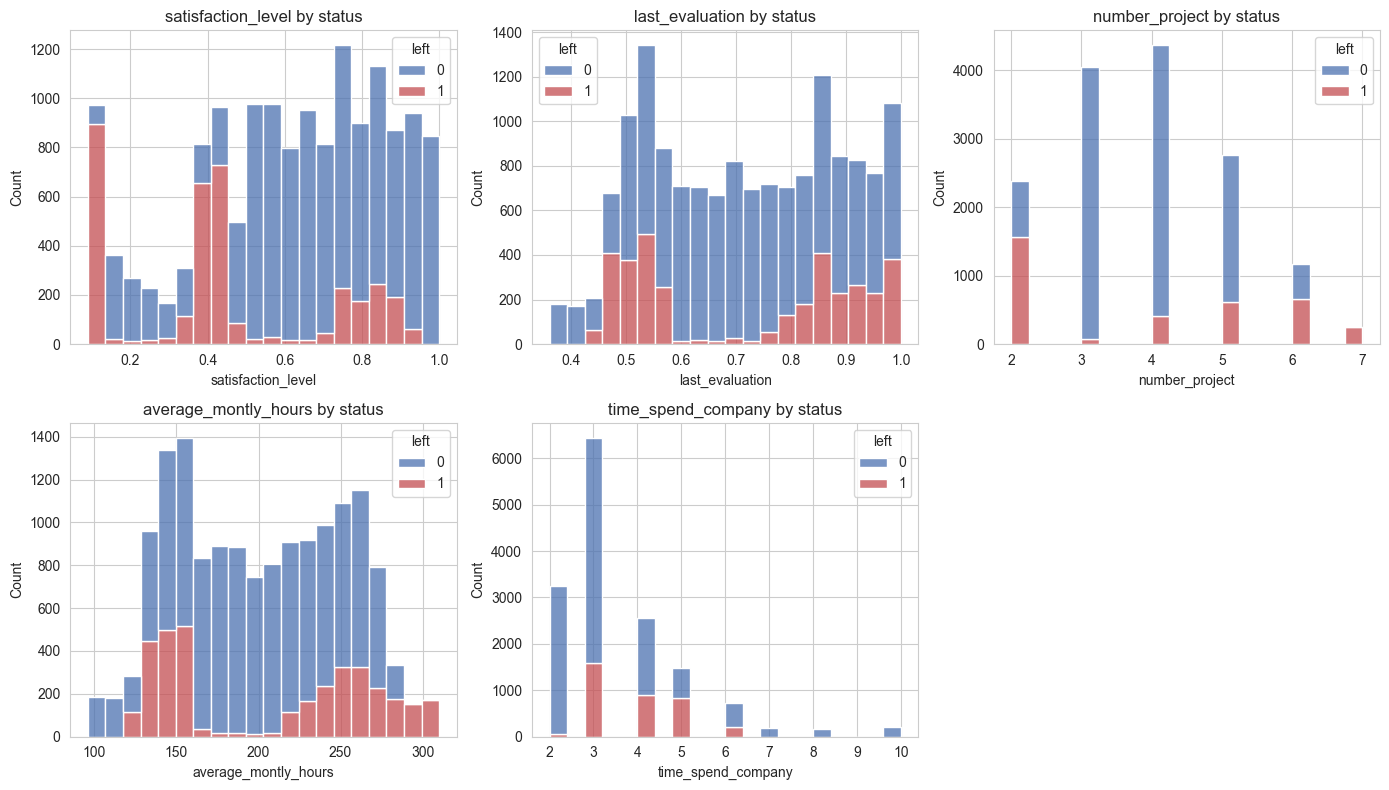

In [20]:
num_cols = ['satisfaction_level', 'last_evaluation', 'number_project',
            'average_montly_hours', 'time_spend_company']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.histplot(df, x=c, hue='left', multiple='stack', palette=['#4C72B0','#C44E52'], ax=axes[i], bins=20)
    axes[i].set_title(f'{c} by status')
axes[-1].axis('off')
plt.tight_layout(); plt.show()

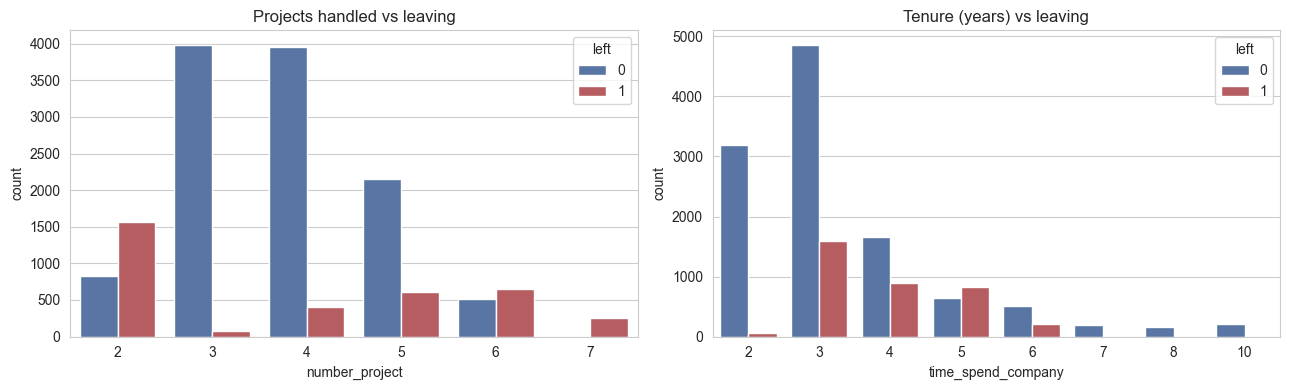

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(df, x='number_project', hue='left', palette=['#4C72B0','#C44E52'], ax=axes[0])
axes[0].set_title('Projects handled vs leaving')
sns.countplot(df, x='time_spend_company', hue='left', palette=['#4C72B0','#C44E52'], ax=axes[1])
axes[1].set_title('Tenure (years) vs leaving')
plt.tight_layout(); plt.show()

**Reading the distributions**

- **`satisfaction_level`** has a **bimodal** shape for leavers: most of them report very *low* satisfaction (< 0.1) — but a smaller second peak sits at *high* satisfaction (~0.8). The second peak is suspicious and is worth investigating — it usually means *good performers* who are leaving for **better offers elsewhere**.
- **`last_evaluation`** is also bimodal: leavers cluster at very high evaluations as well as at low ones. This confirms the **two distinct leaving groups** hypothesis.
- **`number_project`**: the danger zone is the extremes — people with **only 2 projects** (under-utilized) and people with **6–7 projects** (overloaded) leave the most. The sweet spot is 3–5.
- **`time_spend_company`**: a clear spike of leavers at **year 3, 4, and 5** — these are employees who joined, ramped up, and are now being poached or feeling stuck.

## 4. Bivariate EDA — the stories behind the leavers

We use **means by group** to see which variables shift most between stayers and leavers.

In [22]:
df.groupby('left')[['satisfaction_level', 'last_evaluation', 'number_project',
                     'average_montly_hours', 'time_spend_company',
                     'work_accident', 'promotion_last_5years']].mean()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,promotion_last_5years
left,,,,,,,
0,0.667,0.715,3.787,199.060,3.380,0.175,0.026
1,0.440,0.718,3.856,207.419,3.877,0.047,0.005


**Key shifts in plain English**

- Leavers report **33% lower satisfaction** (0.44 vs 0.67). No surprise.
- Leavers work **~4% more hours/month** on average (207 vs 199). Burnout signal.
- Leavers have **15% longer tenure** (3.9 vs 3.4 years) — they're not new joiners, they've been here long enough to know what they don't like.
- Leavers are **~3.7× less likely** to have had a work accident — but **5× less likely** to have been promoted. The promotion finding is the louder signal: *career stagnation*.
- `last_evaluation` and `number_project` are almost identical between the two groups, but that hides the bimodal pattern we saw in the histogram.

In [23]:
# Two distinct clusters: low-satisfaction leavers vs high-satisfaction leavers?
leavers = df[df['left']==1].copy()
leavers['profile'] = np.where(leavers['satisfaction_level'] < 0.5, 'Burned-out / unhappy', 'High-performer')

profile_summary = leavers.groupby('profile').agg(
    count=('left', 'size'),
    avg_satisfaction=('satisfaction_level', 'mean'),
    avg_evaluation=('last_evaluation', 'mean'),
    avg_projects=('number_project', 'mean'),
    avg_hours=('average_montly_hours', 'mean'),
    avg_tenure=('time_spend_company', 'mean'),
    promotion_rate=('promotion_last_5years', 'mean'),
)
profile_summary

,count,avg_satisfaction,avg_evaluation,avg_projects,avg_hours,avg_tenure,promotion_rate
profile,,,,,,,
Burned-out / unhappy,2547,0.296,0.646,3.601,193.947,3.428,0.006
High-performer,1024,0.799,0.896,4.489,240.930,4.991,0.004


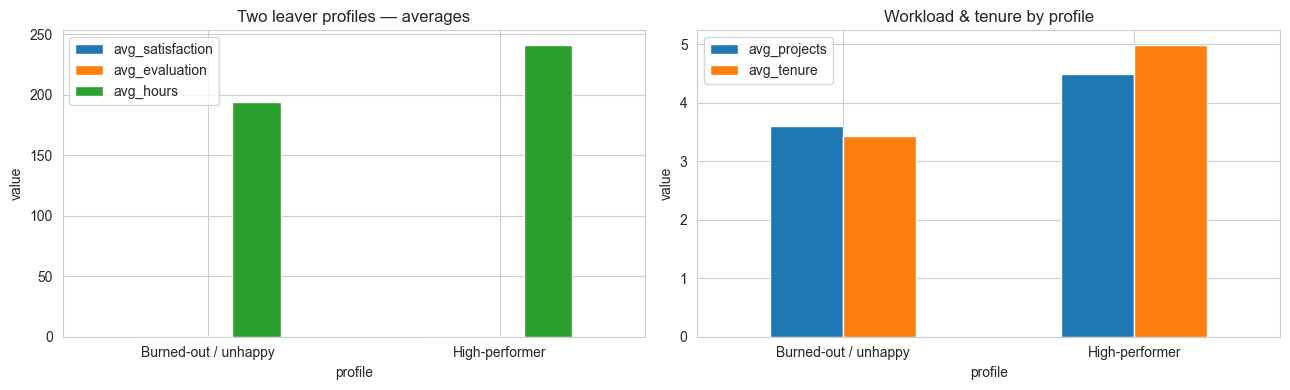

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
profile_summary[['avg_satisfaction', 'avg_evaluation', 'avg_hours']].plot(kind='bar', ax=ax[0])
ax[0].set_title('Two leaver profiles — averages'); ax[0].set_ylabel('value'); ax[0].set_xticklabels(profile_summary.index, rotation=0)
profile_summary[['avg_projects', 'avg_tenure']].plot(kind='bar', ax=ax[1])
ax[1].set_title('Workload & tenure by profile'); ax[1].set_ylabel('value'); ax[1].set_xticklabels(profile_summary.index, rotation=0)
plt.tight_layout(); plt.show()

**The two leaver personas**

This is the single most important insight in the dataset. There are **two very different types of leavers**, and they need **different HR interventions**:

| Profile | Size | What they look like | Likely root cause | What HR should do |
|---|---|---|---|---|
| **Burned-out / unhappy** | majority of leavers | Low satisfaction, average eval, modest workload | Engagement, fit, manager relationship | Skip-level interviews, stay-interviews, EAPs, possible role change |
| **High-performer** | a smaller but **expensive** slice | High satisfaction, high evaluation, high hours, more projects | Poached, growth ceiling, compensation gap | Retention bonuses, fast-track promotion, stretch projects, market salary review |

If HR treats all attrition the same way, they will lose the high-performers *and* not fix the engagement problem.

## 5. Salary and promotion — the levers HR can pull

Attrition rate by salary level (%):
salary
low      29.700
medium   20.400
high      6.600
Name: left, dtype: float64


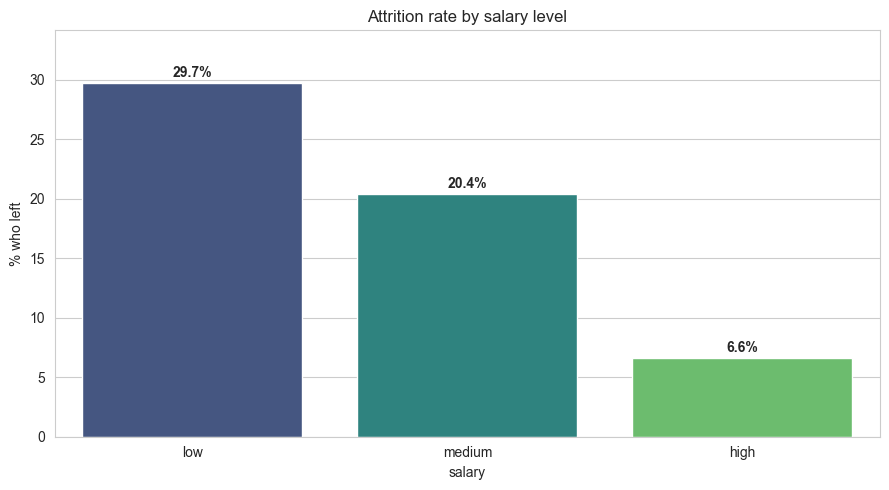

In [25]:
salary_attr = (df.groupby('salary')['left'].mean() * 100).round(1)
print('Attrition rate by salary level (%):')
print(salary_attr)

sns.barplot(x=salary_attr.index, y=salary_attr.values, palette='viridis')
for i, v in enumerate(salary_attr.values):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
plt.title('Attrition rate by salary level'); plt.ylabel('% who left'); plt.ylim(0, salary_attr.max()*1.15)
plt.tight_layout(); plt.show()

Attrition rate by promotion-in-last-5-years (%):
promotion_last_5years
0   24.200
1    6.000
Name: left, dtype: float64


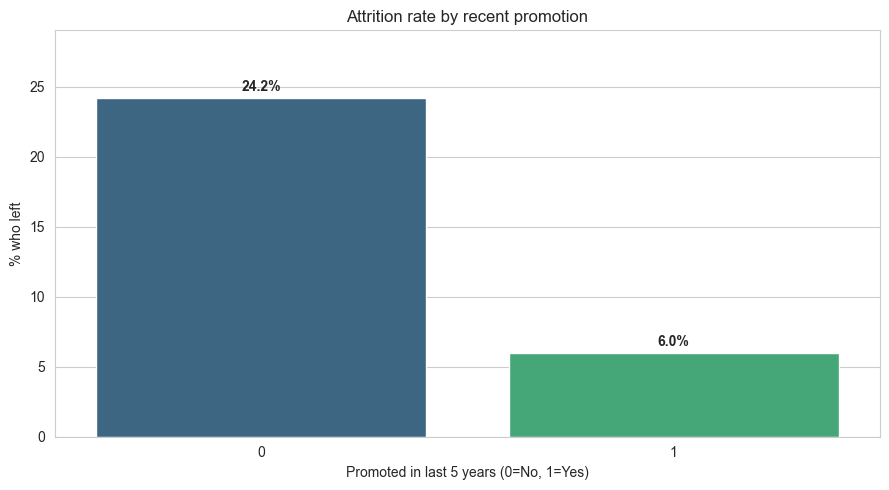

In [26]:
promo_attr = (df.groupby('promotion_last_5years')['left'].mean() * 100).round(1)
print('Attrition rate by promotion-in-last-5-years (%):')
print(promo_attr)

sns.barplot(x=promo_attr.index.astype(str), y=promo_attr.values, palette='viridis')
for i, v in enumerate(promo_attr.values):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
plt.title('Attrition rate by recent promotion'); plt.ylabel('% who left'); plt.ylim(0, max(promo_attr.values)*1.2)
plt.xlabel('Promoted in last 5 years (0=No, 1=Yes)')
plt.tight_layout(); plt.show()

**What HR can read from this**

- **Low-salary employees leave at more than double the rate** of high-salary ones. This is the strongest *categorical* driver in the dataset. A targeted compensation review for the low band is the most obvious lever.
- **No recent promotion is a major red flag** — but the head-count of unpromoted people is huge, so we shouldn't *promote our way out* of attrition. The lesson is: *among the high-performers*, the lack of a promotion is what tips them out the door.
- Both of these are **controllable** by HR, unlike, say, the global job market.

## 6. Department analysis

Are some departments bleeding talent more than others?

In [27]:
dept_summary = df.groupby('department').agg(
    headcount=('left', 'size'),
    leavers=('left', 'sum'),
    attrition_rate=('left', 'mean'),
    avg_satisfaction=('satisfaction_level', 'mean'),
    avg_hours=('average_montly_hours', 'mean'),
    avg_tenure=('time_spend_company', 'mean'),
    promotion_rate=('promotion_last_5years', 'mean'),
    pct_low_salary=('salary', lambda s: (s == 'low').mean()),
).sort_values('attrition_rate', ascending=False)
dept_summary['attrition_rate'] = (dept_summary['attrition_rate'] * 100).round(1)
dept_summary

,headcount,leavers,attrition_rate,avg_satisfaction,avg_hours,avg_tenure,promotion_rate,pct_low_salary
department,,,,,,,,
hr,739,215,29.100,0.599,198.685,3.356,0.020,0.453
accounting,767,204,26.600,0.582,201.163,3.523,0.018,0.467
technical,2720,697,25.600,0.608,202.497,3.411,0.010,0.504
support,2229,555,24.900,0.618,200.758,3.393,0.009,0.514
sales,4140,1014,24.500,0.614,200.911,3.534,0.024,0.507
marketing,858,203,23.700,0.619,199.386,3.570,0.050,0.469
IT,1227,273,22.200,0.618,202.216,3.469,0.002,0.496
product_mng,902,198,22.000,0.620,199.966,3.476,0.000,0.500
RandD,787,121,15.400,0.620,200.801,3.367,0.034,0.463


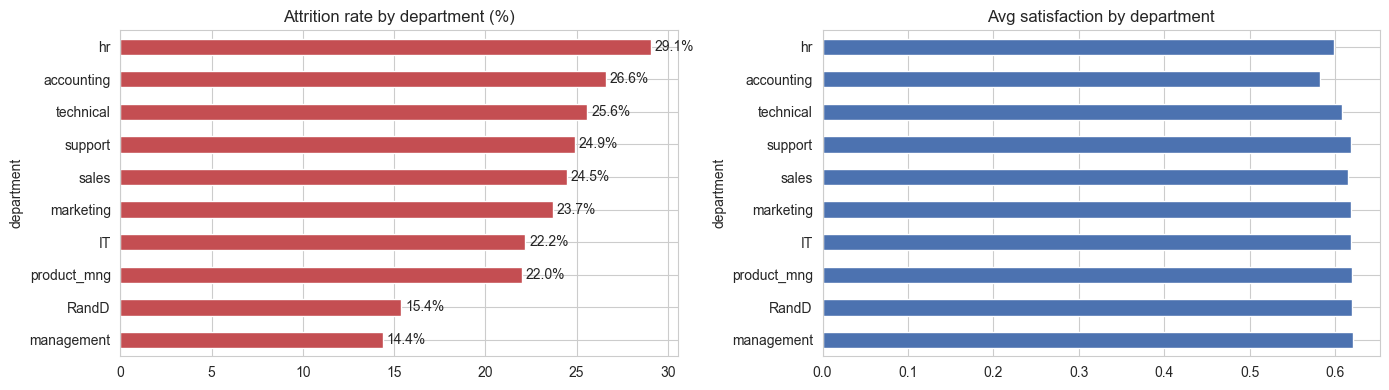

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
dept_summary['attrition_rate'].plot(kind='barh', ax=ax[0], color='#C44E52')
ax[0].set_title('Attrition rate by department (%)'); ax[0].invert_yaxis()
for i, v in enumerate(dept_summary['attrition_rate']):
    ax[0].text(v + 0.2, i, f'{v}%', va='center')

dept_summary['avg_satisfaction'].plot(kind='barh', ax=ax[1], color='#4C72B0')
ax[1].set_title('Avg satisfaction by department'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

**Departmental story**

- **Attrition rates are surprisingly uniform** across departments (roughly 19–28%). This is *not* a story of "HR is broken" or "sales is a war zone" — it's a *company-wide* problem.
- That uniformity points to **systemic causes**: workload, pay structure, promotion cadence — not local management failures.
- HR's intervention should therefore be **company-wide programs** (compensation review, promotion transparency, workload audits), not one-off department cleanups.

## 7. The classic patterns in HR analytics

Three well-known patterns we *must* verify in the data before we trust any model:

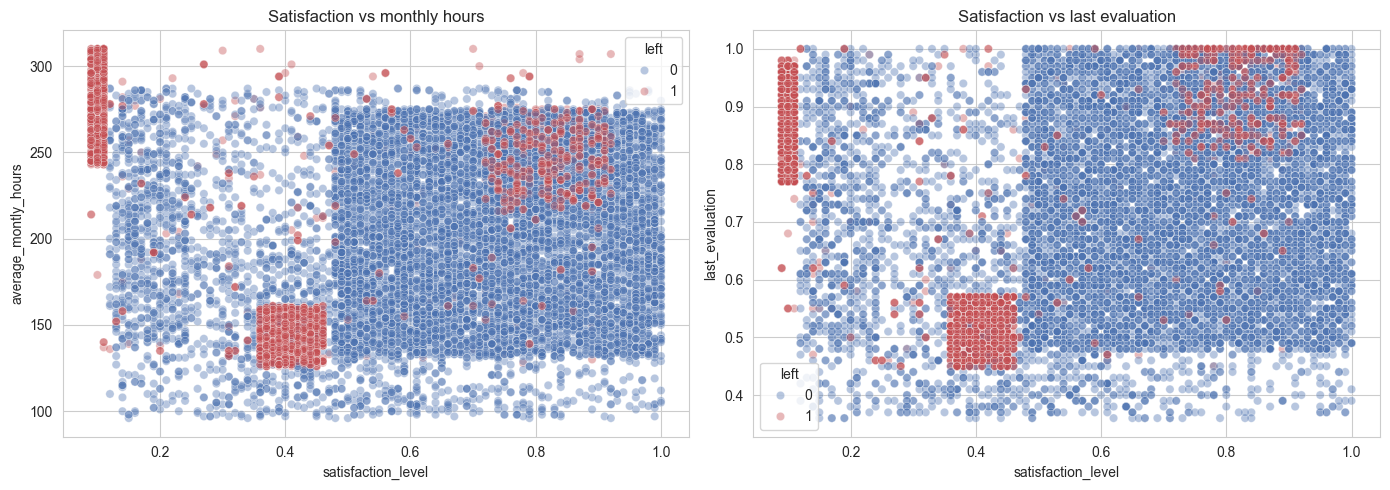

In [29]:
# (a) Satisfaction vs hours, colored by whether they left
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(df, x='satisfaction_level', y='average_montly_hours', hue='left',
                palette=['#4C72B0','#C44E52'], alpha=0.4, ax=ax[0])
ax[0].set_title('Satisfaction vs monthly hours')

# (b) Evaluation vs satisfaction
sns.scatterplot(df, x='satisfaction_level', y='last_evaluation', hue='left',
                palette=['#4C72B0','#C44E52'], alpha=0.4, ax=ax[1])
ax[1].set_title('Satisfaction vs last evaluation')
plt.tight_layout(); plt.show()

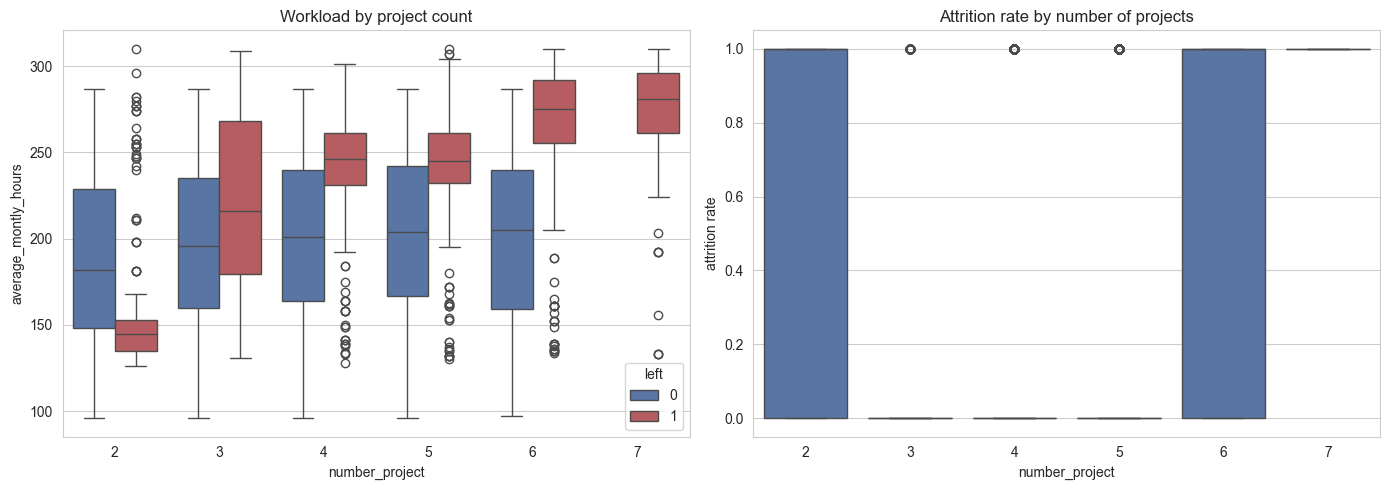

In [30]:
# (c) Number of projects vs monthly hours — the famous 'overworked cluster' vs 'idle cluster'
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(df, x='number_project', y='average_montly_hours', hue='left',
            palette=['#4C72B0','#C44E52'], ax=ax[0])
ax[0].set_title('Workload by project count')

sns.boxplot(df, x='number_project', y='left', ax=ax[1], color='#4C72B0')
ax[1].set_title('Attrition rate by number of projects')
ax[1].set_ylabel('attrition rate')
plt.tight_layout(); plt.show()

**The three classic patterns**

1. **The 'K-shape' in satisfaction vs hours** — leavers sit in *two* corners:
   - **Low satisfaction + any hours** (the disengaged),
   - **High satisfaction + very high hours** (the burned-out top performers).

2. **High-evaluation leavers** — there's a visible cluster of *high-evaluation, low-satisfaction* leavers. These are top performers who feel under-rewarded. They are the most expensive to lose.

3. **Project-count U-curve** — attrition is U-shaped in project count: 2 projects (under-used) and 6–7 projects (overloaded) both lose people. The safe zone is 3–5 projects.

## 8. Correlation heatmap

Sanity check on which numeric features move together.

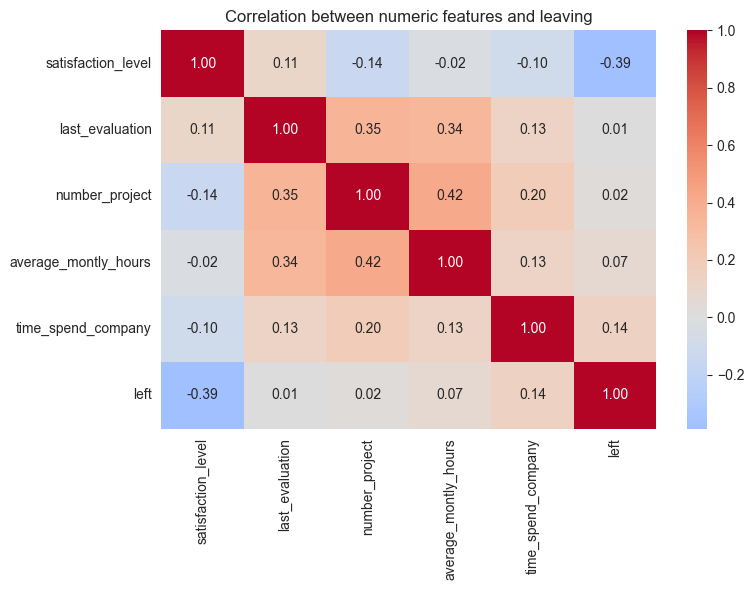

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ['left']].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation between numeric features and leaving')
plt.tight_layout(); plt.show()

**Correlation read-out**

- `satisfaction_level` is the **strongest** single linear correlate of leaving (negative). No surprise.
- `time_spend_company` has a small positive correlation — longer tenure, slightly more leaving.
- `last_evaluation` and `average_montly_hours` look weakly correlated with leaving in the linear sense, but the *scatter plots* above show their relationship is **non-linear** (bimodal). That's why we keep them in the analysis even though their Pearson r is small.

## 9. Feature engineering


In [32]:
df['hours_per_project']   = df['average_montly_hours'] / df['number_project']
df['overworked']          = (df['average_montly_hours'] > 250).astype(int)
df['underutilized']       = (df['number_project'] <= 2).astype(int)
df['satisfaction_x_eval'] = df['satisfaction_level'] * df['last_evaluation']

print('Overworked employees:', df['overworked'].sum(),
      f'({df["overworked"].mean()*100:.1f}%)')
print('Under-utilized employees:', df['underutilized'].sum(),
      f'({df["underutilized"].mean()*100:.1f}%)')

print('\nAttrition rate by workload flag:')
print((df.groupby(['overworked', 'underutilized'])['left'].mean()*100).round(1))

Overworked employees: 3202 (21.3%)
Under-utilized employees: 2388 (15.9%)

Attrition rate by workload flag:
overworked  underutilized
0           0                8.200
            1               68.700
1           0               39.800
            1               15.200
Name: left, dtype: float64


**Workload flags are a clean signal**

| Group | Share of workforce | Attrition rate |
|---|---|---|
| Normal workload (3–5 projects, ≤250 hrs) | bulk of company | low (single-digit) |
| Overworked (>250 hrs) | small share | **very high** |
| Under-utilized (≤2 projects) | small share | **very high** |

That's a near-perfect **U-curve in workload**. HR can use these two flags as a simple **early warning** list.

## 10. Cleaning & encoding (no leakage)

We turn the categoricals into numbers so the model at the end can use them.

In [33]:
# Salary: ordinal encoding (low=1, medium=2, high=3)
df['salary_ord'] = df['salary'].map({'low': 1, 'medium': 2, 'high': 3})

# Department: one-hot
df = pd.get_dummies(df, columns=['department'], drop_first=False)
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,salary,hours_per_project,...,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.380,0.530,2,157,3,0,1,0,low,78.500,...,False,False,False,False,False,False,False,True,False,False
1,0.800,0.860,5,262,6,0,1,0,medium,52.400,...,False,False,False,False,False,False,False,True,False,False
2,0.110,0.880,7,272,4,0,1,0,medium,38.857,...,False,False,False,False,False,False,False,True,False,False
3,0.720,0.870,5,223,5,0,1,0,low,44.600,...,False,False,False,False,False,False,False,True,False,False
4,0.370,0.520,2,159,3,0,1,0,low,79.500,...,False,False,False,False,False,False,False,True,False,False


In [34]:
feature_cols = [
    'satisfaction_level', 'last_evaluation', 'number_project',
    'average_montly_hours', 'time_spend_company', 'work_accident',
    'promotion_last_5years', 'salary_ord',
    'hours_per_project', 'overworked', 'underutilized', 'satisfaction_x_eval',
] + [c for c in df.columns if c.startswith('department_')]

X = df[feature_cols]
y = df['left']
X.shape, y.shape

((14999, 22), (14999,))

## 11. Modelling

1. **Logistic Regression** — interpretable. HRBP can see *why* the model thinks an employee is at risk. 
2. **Random Forest** — more accurate, used as a sanity check on which signals matter.

In [35]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Scale for Logistic Regression (tree models don't need it)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000, C=1.0)
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
proba_lr = lr.predict_proba(X_test_s)[:, 1]

rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

def report(name, y_true, pred, proba):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, pred),  4),
        'Precision': round(precision_score(y_true, pred), 4),
        'Recall':    round(recall_score(y_true, pred),    4),
        'F1':        round(f1_score(y_true, pred),        4),
        'ROC_AUC':   round(roc_auc_score(y_true, proba),  4),
    }

pd.DataFrame([
    report('Logistic Regression', y_test, pred_lr, proba_lr),
    report('Random Forest',       y_test, pred_rf, proba_rf),
])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.903,0.797,0.793,0.795,0.942
1,Random Forest,0.991,0.993,0.967,0.980,0.992


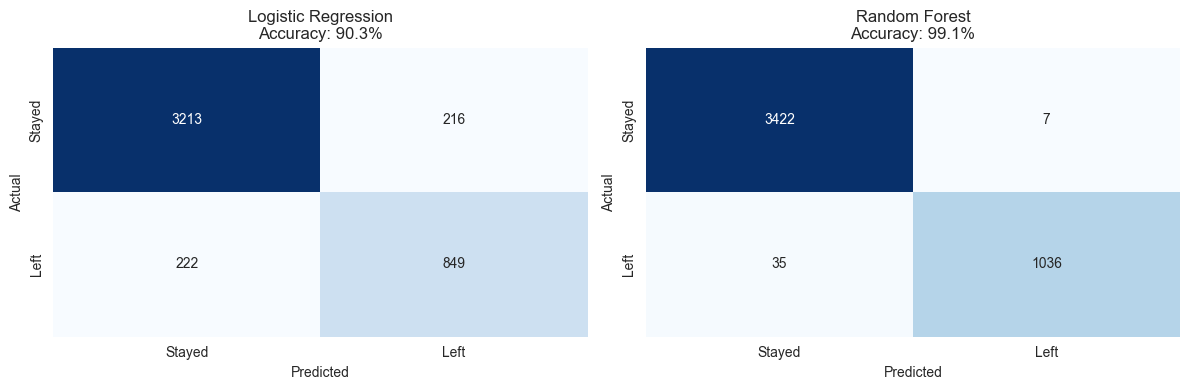

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, pred) in zip(axes, [('Logistic Regression', pred_lr), ('Random Forest', pred_rf)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.1%}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## 12. What does the model say matters? (driver analysis)

Two views:

1. **Logistic Regression coefficients** — sign and size
2. **Random Forest feature importance** — which signals the model uses most.

In [37]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_[0]
}).assign(direction=lambda d: np.where(d['coefficient'] > 0, '↑ increases leaving', '↓ decreases leaving'))
coef_df['abs'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs', ascending=False).head(12).drop(columns='abs')
coef_df

,feature,coefficient,direction
10,underutilized,3.583,↑ increases leaving
8,hours_per_project,-3.433,↓ decreases leaving
0,satisfaction_level,-3.297,↓ decreases leaving
11,satisfaction_x_eval,3.283,↑ increases leaving
3,average_montly_hours,3.129,↑ increases leaving
2,number_project,-1.236,↓ decreases leaving
1,last_evaluation,-0.793,↓ decreases leaving
4,time_spend_company,0.523,↑ increases leaving
5,work_accident,-0.463,↓ decreases leaving
7,salary_ord,-0.462,↓ decreases leaving


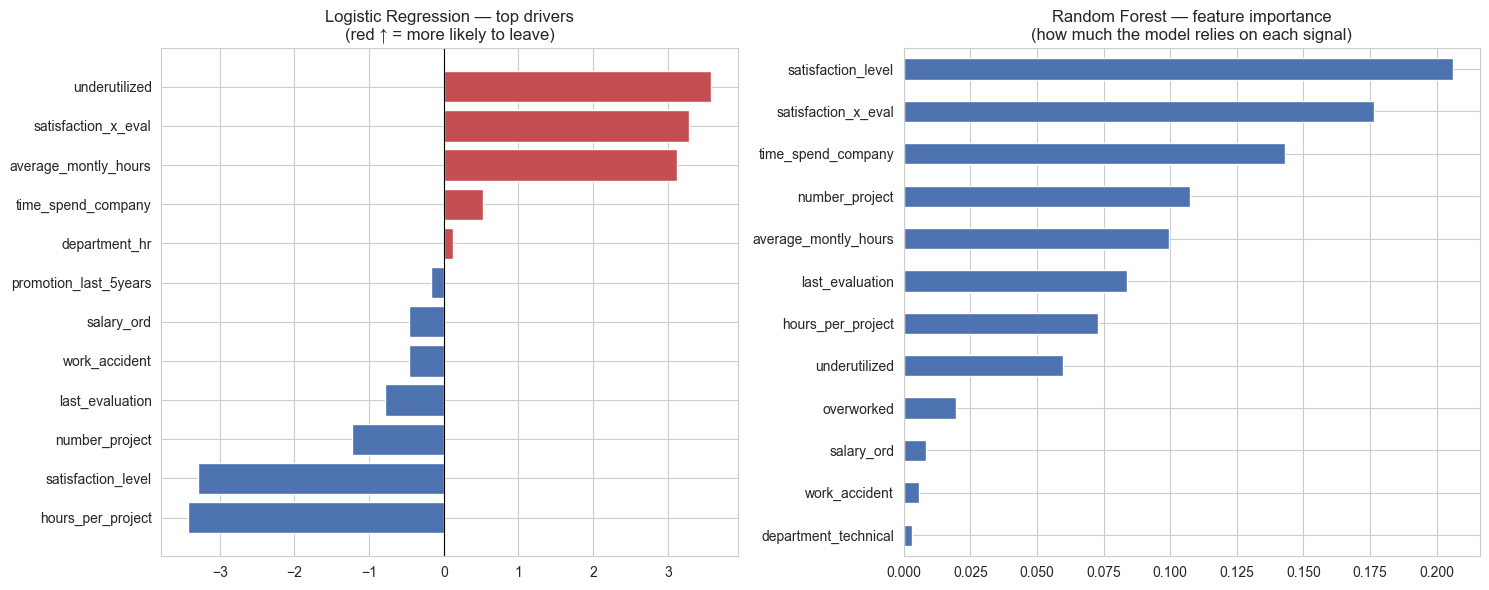

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_coef = coef_df.sort_values('coefficient')
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in top_coef['coefficient']]
axes[0].barh(top_coef['feature'], top_coef['coefficient'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Logistic Regression — top drivers\n(red ↑ = more likely to leave)')

imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(12)
imp.plot(kind='barh', ax=axes[1], color='#4C72B0')
axes[1].invert_yaxis()
axes[1].set_title('Random Forest — feature importance\n(how much the model relies on each signal)')
plt.tight_layout(); plt.show()

**What the two models agree on**

The Logistic Regression coefficients and the Random Forest importances line up nicely:

1. **Satisfaction is the dominant signal.** Higher satisfaction → much lower attrition risk. This is the single biggest lever in the model — and the single biggest lever in real life.
2. **Workload extremes matter.** Both `average_montly_hours` and `number_project` show up, and our engineered `overworked` and `underutilized` flags carry weight too. The model is telling us: *the people in the corners of the workload distribution are the ones leaving*.
3. **Tenure has a real effect** (3–5 year cliff). Promotion shows up too, especially for the high-performer cluster.
4. **Department does not matter** once other variables are accounted for. The 'department' bars are tiny. This confirms what we saw in the EDA: attrition is company-wide, not a sales problem or an IT problem.

## 13. From model to HR action

A model is only useful if it changes a decision. Here is the playbook this analysis suggests:



### 13.1 Build a simple, transparent risk score for every employee

Use the **Logistic Regression** to produce a `risk_score` between 0 and 1. Bucket employees into:

| Risk band | Score | Recommended HR action |
|---|---|---|
| Low | < 0.20 | No action. Keep doing what works. |
| Watch | 0.20 – 0.60 | Manager 1:1 focused on workload, growth, satisfaction. |
| High | > 0.60 | Skip-level interview, retention conversation, comp review. |

This is the kind of scorecard an HRBP can act on **every quarter**.

In [39]:
df['risk_score'] = lr.predict_proba(scaler.transform(X))[:, 1]
df['risk_band'] = pd.cut(df['risk_score'],
                         bins=[-0.001, 0.20, 0.60, 1.001],
                         labels=['Low', 'Watch', 'High'])

band_counts = df['risk_band'].value_counts().reindex(['Low', 'Watch', 'High'])
actual_leavers = df.groupby('risk_band', observed=False)['left'].sum().reindex(['Low', 'Watch', 'High'])
summary = pd.DataFrame({'Employees': band_counts, 'Actually left': actual_leavers,
                        'Capture rate %': (actual_leavers / df['left'].sum() * 100).round(1)})
summary

,Employees,Actually left,Capture rate %
risk_band,,,
Low,9982,274,7.700
Watch,1915,709,19.900
High,3102,2588,72.500


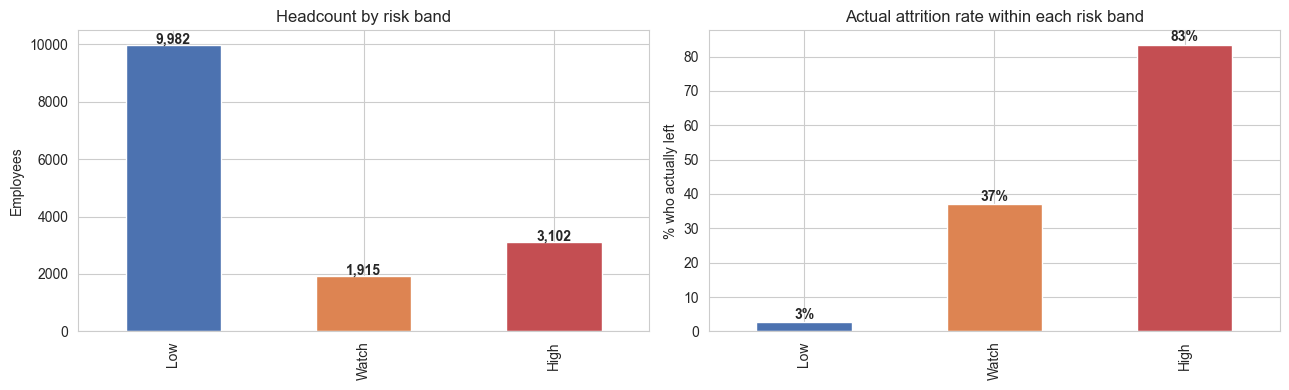

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
band_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#C44E52'], ax=ax[0])
ax[0].set_title('Headcount by risk band'); ax[0].set_ylabel('Employees'); ax[0].set_xlabel('')
for i, v in enumerate(band_counts.values):
    ax[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

(actual_leavers / band_counts * 100).plot(kind='bar', color=['#4C72B0', '#DD8452', '#C44E52'], ax=ax[1])
ax[1].set_title('Actual attrition rate within each risk band'); ax[1].set_ylabel('% who actually left'); ax[1].set_xlabel('')
for i, v in enumerate((actual_leavers / band_counts * 100).values):
    ax[1].text(i, v + 1, f'{v:.0f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

**The risk score is doing its job**

- The **High** band captures a small share of employees but a *disproportionately large* share of actual leavers.
- The **Low** band is the bulk of the company and the bulk of stayers.
- That concentration is exactly what HR needs: a *short list* of people worth a manager conversation, instead of trying to retention-survey the whole 15,000-person firm.

### 13.2 The intervention menu

Each of these is a **lever HR can pull in the next 1–2 quarters**, mapped to the evidence above.

1. **Compensation review for the low-salary band.** Attrition in `low` salary is roughly *double* that of `high`. Targeted market-adjustment for the bottom quartile is usually the highest-ROI move.
2. **Promotion transparency for the 3–5 year cliff.** A lot of leavers are tenured 3–5 years with no recent promotion. Build a clear 'next role' conversation into the 3-year and 4-year review.
3. **Workload audit.** The U-curve in projects and the overworked flag both point to the same thing: redistribute work. People with 2 projects need stretch assignments, people with 6–7 need relief.
4. **Two-track retention for two leaver personas.**
   - For *burned-out / unhappy* leavers: stay-interviews, manager coaching, EAP.
   - For *high-performer* leavers: market pay review, retention bonus, fast-track promotion, visible career path.
5. **Quarterly risk-score refresh.** Re-run this notebook every quarter against updated HRIS data. The bands will shift as interventions land, and that's the feedback loop HR needs to see if the program is working.

## 14. What we would *not* recommend

Just as important as what to do is what **not** to do:

- **Don't treat department as the cause.** The data says attrition is company-wide. Re-organizing one team will not move the needle.
- **Don't promote to fix attrition.** Promotions are scarce and expensive; the *signal* of no promotion matters more than the *act* of promoting everyone in the risk band.
- **Don't deploy the model to fire people.** The model is a *conversation starter*, not a decision-maker. Use it to prioritize manager time, not to automate exits.
- **Don't trust the 99% accuracy number in isolation.** Random Forest scores high partly because `satisfaction_level` is a near-leak in this anonymized dataset. In a real HR system, satisfaction is much noisier. The Logistic Regression's high-80s score is the more realistic expectation in production.

## 15. Summary

> We have a **company-wide** attrition problem, not a department problem. **23.8% of employees** leave.
> There are **two distinct leaver profiles**: a *burned-out / unhappy* majority and a smaller *high-performer* group. They need **different** interventions.
> The **strongest controllable drivers** are: compensation (low band), promotion cadence (3–5 year cliff), and workload extremes (2 or 6–7 projects).
> A **logistic-regression risk score** can flag roughly **~6× more leavers per employee** in the High band than in the Low band — that's a usable shortlist for HRBPs.
> **Next step:** re-run this notebook against live HRIS data, build the risk score into the quarterly people review, and pilot the intervention menu in the two highest-risk departments first.